# error_increased_Gaussian_noise demo

使用 `error_increased_Gaussian_noise` 在不同参数下计算并绘图。

## 1. 导入依赖与本地函数

In [21]:
import os
import sys

import numpy as np
import matplotlib.pyplot as plt

# Allow local import of qrk_adv
repo_root = os.path.abspath(os.path.join(os.getcwd()))
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)

from qrk_adv.noise import error_increased_Gaussian_noise
from qrk_adv.quantile import half_normal_quantile, sigma_min_alpha0_square

## 2. 设置参数与采样网格

In [23]:
np.linspace(0, 1, 1)

array([0.])

In [17]:
q = 1 - 0.0000135422
beta = 0.2
sigma_min = 0.1
sigma_max = 10
num_points = 10
sigma_grid = np.linspace(sigma_min, sigma_max, num_points)
results = []

phi_q = half_normal_quantile(q)
error_decrease = sigma_min_alpha0_square(q, q)

c(q_cond) nonincreasing? False
c(q_cond) nondecreasing? True
min c at q_cond= 0.39999999999999997


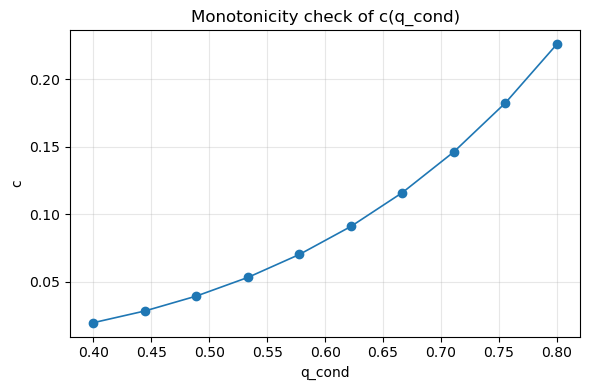

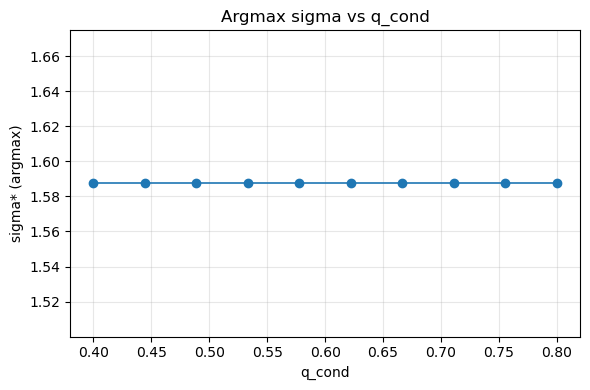

In [25]:
# Check monotonicity of c(q_cond) over the q-grid.
q = 0.6
beta = 0.2
num_grid_Q = 10
sigma_grid = np.linspace(0.01, 10, 20)
alpha_0 = q - beta
alpha_prime = 1.0 - q - beta
q_grid = np.linspace(alpha_0, 1.0 - alpha_prime, num_grid_Q)

c_vals = []
sigma_argmax = []
for q_cond in q_grid:
    decrease = (1 - beta) * sigma_min_alpha0_square(q_cond, q)
    phi_q_cond = half_normal_quantile(q_cond)
    vals = [error_increased_Gaussian_noise(phi_q_cond, s) for s in sigma_grid]
    max_idx = int(np.argmax(vals))
    c_val = decrease - beta * vals[max_idx]
    c_vals.append(c_val)
    sigma_argmax.append(sigma_grid[max_idx])

c_vals = np.array(c_vals)
sigma_argmax = np.array(sigma_argmax)
diffs = np.diff(c_vals)
tol = 1e-10
is_nonincreasing = np.all(diffs <= tol)
is_nondecreasing = np.all(diffs >= -tol)

print("c(q_cond) nonincreasing?", is_nonincreasing)
print("c(q_cond) nondecreasing?", is_nondecreasing)
print("min c at q_cond=", q_grid[int(np.argmin(c_vals))])

plt.figure(figsize=(6, 4))
plt.plot(q_grid, c_vals, marker="o", lw=1.2, label="c(q_cond)")
plt.xlabel("q_cond")
plt.ylabel("c")
plt.title("Monotonicity check of c(q_cond)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(q_grid, sigma_argmax, marker="o", lw=1.2, label="argmax sigma")
plt.xlabel("q_cond")
plt.ylabel("sigma* (argmax)")
plt.title("Argmax sigma vs q_cond")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 3. 计算 error_increased_Gaussian_noise 并绘图

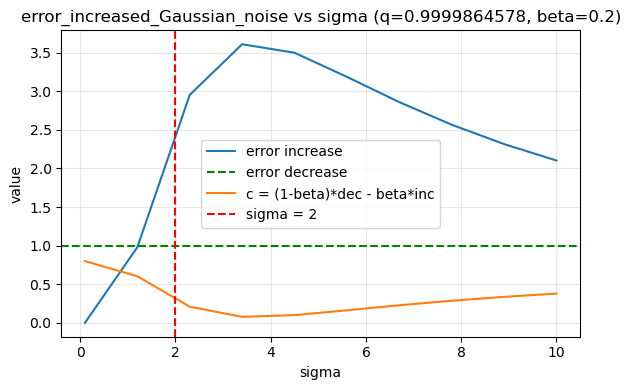

In [18]:
for sigma in sigma_grid:
    results.append(error_increased_Gaussian_noise(phi_q, sigma))

results = np.array(results, dtype=float)

# Compare increase vs decrease and a simple net c (no S_star_penalty).
c_values = (1 - beta) * error_decrease - beta * results

plt.figure(figsize=(6, 4))
plt.plot(sigma_grid, results, label="error increase")
plt.axhline(y=error_decrease, color="g", linestyle="--", label="error decrease")
plt.plot(sigma_grid, c_values, label="c = (1-beta)*dec - beta*inc")
plt.axvline(x=2.0, color="r", linestyle="--", label="sigma = 2")
plt.xlabel("sigma")
plt.ylabel("value")
plt.title(f"error_increased_Gaussian_noise vs sigma (q={q}, beta={beta})")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4. 可选：扫描 q 或 sigma 观察变化

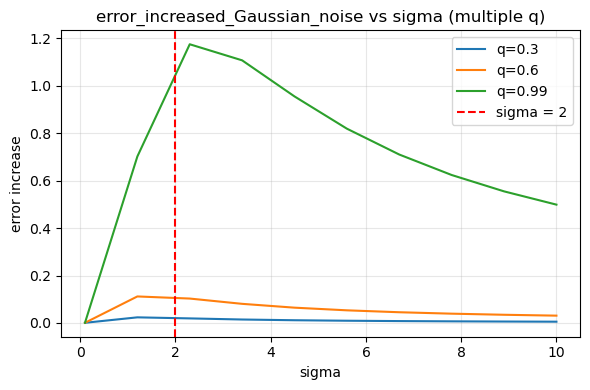

In [5]:
q_list = [0.3, 0.6, 0.99]

plt.figure(figsize=(6, 4))
for q_val in q_list:
    phi_q_val = half_normal_quantile(q_val)
    vals = [error_increased_Gaussian_noise(phi_q_val, s) for s in sigma_grid]
    plt.plot(sigma_grid, vals, label=f"q={q_val}")

plt.axvline(x=2.0, color="r", linestyle="--", label="sigma = 2")
plt.xlabel("sigma")
plt.ylabel("error increase")
plt.title("error_increased_Gaussian_noise vs sigma (multiple q)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()